In [1]:
import pandas as pd

df = pd.read_csv("../data/sample_emails.csv")
df.head()

,id,sender,subject,body,priority,label
0,1,hr@company.com,Offer Letter - Please Sign,"Dear Candidate, Congratulations! Please sign a...",high,important
1,2,noreply@shopping.com,Big Billion Sale is Live,Flat 70% OFF on electronics. Limited period of...,low,promotion
2,3,alerts@mybank.com,Unusual Login Attempt,We detected a login attempt to your account fr...,high,security
3,4,newsletter@blog.com,Weekly Tech Newsletter,"In this week's edition, learn about AI agents,...",low,newsletter
4,5,friend123@gmail.com,Coffee this weekend?,"Hey, long time no see! Are you free this weeke...",medium,personal


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        8 non-null      int64 
 1   sender    8 non-null      object
 2   subject   8 non-null      object
 3   body      8 non-null      object
 4   priority  8 non-null      object
 5   label     8 non-null      object
dtypes: int64(1), object(5)
memory usage: 516.0+ bytes


In [3]:
df.describe(include="all")

,id,sender,subject,body,priority,label
count,8.00000,8,8,8,8,8
unique,NaN,8,8,8,3,7
top,NaN,hr@company.com,Offer Letter - Please Sign,"Dear Candidate, Congratulations! Please sign a...",high,work
freq,NaN,1,1,1,4,2
mean,4.50000,NaN,NaN,NaN,NaN,NaN
std,2.44949,NaN,NaN,NaN,NaN,NaN
min,1.00000,NaN,NaN,NaN,NaN,NaN
25%,2.75000,NaN,NaN,NaN,NaN,NaN
50%,4.50000,NaN,NaN,NaN,NaN,NaN
75%,6.25000,NaN,NaN,NaN,NaN,NaN


In [4]:
df["label"].value_counts()

label
work          2
promotion     1
important     1
security      1
newsletter    1
personal      1
spam          1
Name: count, dtype: int64

In [5]:
df['subject'] = df['subject'].fillna('')
df['body'] = df['body'].fillna('')

In [6]:
#Create combined text column
df['text'] = df['subject'] + ' ' + df['body']
df[['text']]

,text
0,"Offer Letter - Please Sign Dear Candidate, Con..."
1,Big Billion Sale is Live Flat 70% OFF on elect...
2,Unusual Login Attempt We detected a login atte...
3,"Weekly Tech Newsletter In this week's edition,..."
4,"Coffee this weekend? Hey, long time no see! Ar..."
5,"You won $1,000,000!!! Click here to claim your..."
6,Project Update Required Please share the statu...
7,Reminder: Complete Mandatory Training Your man...


In [7]:
# show all high priority emails
high_priority = df[df['priority'] == 'high']
high_priority

,id,sender,subject,body,priority,label,text
0,1,hr@company.com,Offer Letter - Please Sign,"Dear Candidate, Congratulations! Please sign a...",high,important,"Offer Letter - Please Sign Dear Candidate, Con..."
2,3,alerts@mybank.com,Unusual Login Attempt,We detected a login attempt to your account fr...,high,security,Unusual Login Attempt We detected a login atte...
5,6,spam@strange-domain.ru,"You won $1,000,000!!!",Click here to claim your lottery now. Do not s...,high,spam,"You won $1,000,000!!! Click here to claim your..."
6,7,manager@company.com,Project Update Required,Please share the status update of your project...,high,work,Project Update Required Please share the statu...


In [8]:
# security-related emails
security_emails = df[df['text'].str.contains('login|password|security', case=False, na=False)]
security_emails

,id,sender,subject,body,priority,label,text
2,3,alerts@mybank.com,Unusual Login Attempt,We detected a login attempt to your account fr...,high,security,Unusual Login Attempt We detected a login atte...
7,8,training@lms.com,Reminder: Complete Mandatory Training,Your mandatory security awareness training is ...,medium,work,Reminder: Complete Mandatory Training Your man...


In [9]:
# promotional/sale emails
promo_emails = df[df['text'].str.contains('sale|discount', case=False, na=False)]
promo_emails

,id,sender,subject,body,priority,label,text
1,2,noreply@shopping.com,Big Billion Sale is Live,Flat 70% OFF on electronics. Limited period of...,low,promotion,Big Billion Sale is Live Flat 70% OFF on elect...


In [10]:
df["priority"].value_counts()

priority
high      4
low       2
medium    2
Name: count, dtype: int64

In [11]:
df.shape

(8, 7)

In [12]:
df.isnull().sum()

id          0
sender      0
subject     0
body        0
priority    0
label       0
text        0
dtype: int64

In [13]:
df.columns

Index(['id', 'sender', 'subject', 'body', 'priority', 'label', 'text'], dtype='object')

In [14]:
df['clean_text']=df['body'].str.lower().str.replace('[^a-zA-Z]', ' ', regex=True)
df[['body', 'clean_text']].head()

,body,clean_text
0,"Dear Candidate, Congratulations! Please sign a...",dear candidate congratulations please sign a...
1,Flat 70% OFF on electronics. Limited period of...,flat off on electronics limited period of...
2,We detected a login attempt to your account fr...,we detected a login attempt to your account fr...
3,"In this week's edition, learn about AI agents,...",in this week s edition learn about ai agents ...
4,"Hey, long time no see! Are you free this weeke...",hey long time no see are you free this weeke...


In [15]:
from collections import Counter

all_words = " ".join(df['clean_text']).split()
word_freq = Counter(all_words)
word_freq.most_common(3)

[('your', 6), ('this', 4), ('please', 3)]

In [16]:
pip install nltk


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))
filtered_words = [w for w in all_words if w not in stop_words]

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\barat\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
# Email: "Please approve the project status update urgently!"

In [ ]:
#Without NLTK
["please","approve","the","project","status","update","urgently"]

#With NLTK Stopword Removal
["please","approve","project","status","update","urgently"]

In [18]:
#Spam Detection Code
import re

SPAM_KEYWORDS = [
    "win", "winner", "lottery", "jackpot",
    "free", "offer", "limited time", "limited period",
    "discount", "sale", "clearance", "deal",
    "click here", "buy now", "urgent",
    "congratulations", "prize"
]

# Compile regex once
pattern = re.compile("|".join(re.escape(w) for w in SPAM_KEYWORDS), re.IGNORECASE)

def is_spam(text: str) -> int:
    if not isinstance(text, str):
        return 0
    return int(bool(pattern.search(text)))


In [19]:
# Ensure subject/body columns exist
if 'subject' not in df.columns:
    df['subject'] = ''

if 'body' not in df.columns:
    df['body'] = ''

# Combine subject and body for detection
df["text"] = df["subject"].fillna("").astype(str) + " " + df["body"].fillna("").astype(str)
df["text"] = df["text"].str.strip()

# Binary spam flag
df["is_spam_rule"] = df["text"].apply(is_spam)

print(df[["id", "subject", "is_spam_rule"]])


   id                                subject  is_spam_rule
0   1             Offer Letter - Please Sign             1
1   2               Big Billion Sale is Live             1
2   3                  Unusual Login Attempt             0
3   4                 Weekly Tech Newsletter             0
4   5                   Coffee this weekend?             1
5   6                  You won $1,000,000!!!             1
6   7                Project Update Required             0
7   8  Reminder: Complete Mandatory Training             0


In [20]:
#Code for Stemming

import pandas as pd
import nltk
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

# Initialize stemmer
stemmer = PorterStemmer()

# Function to apply stemming
def stem_text(text):
    tokens = word_tokenize(text.lower())
    stemmed_words = [stemmer.stem(word) for word in tokens]
    return " ".join(stemmed_words)

# Apply stemming on subject and body
df["subject_stemmed"] = df["subject"].apply(stem_text)
df["body_stemmed"] = df["body"].apply(stem_text)

# Show final dataframe
print(df[["subject", "subject_stemmed", "body", "body_stemmed"]])

                                 subject                   subject_stemmed  \
0             Offer Letter - Please Sign         offer letter - pleas sign   
1               Big Billion Sale is Live          big billion sale is live   
2                  Unusual Login Attempt               unusu login attempt   
3                 Weekly Tech Newsletter              weekli tech newslett   
4                   Coffee this weekend?               coffe thi weekend ?   
5                  You won $1,000,000!!!         you won $ 1,000,000 ! ! !   
6                Project Update Required              project updat requir   
7  Reminder: Complete Mandatory Training  remind : complet mandatori train   

                                                body  \
0  Dear Candidate, Congratulations! Please sign a...   
1  Flat 70% OFF on electronics. Limited period of...   
2  We detected a login attempt to your account fr...   
3  In this week's edition, learn about AI agents,...   
4  Hey, long time

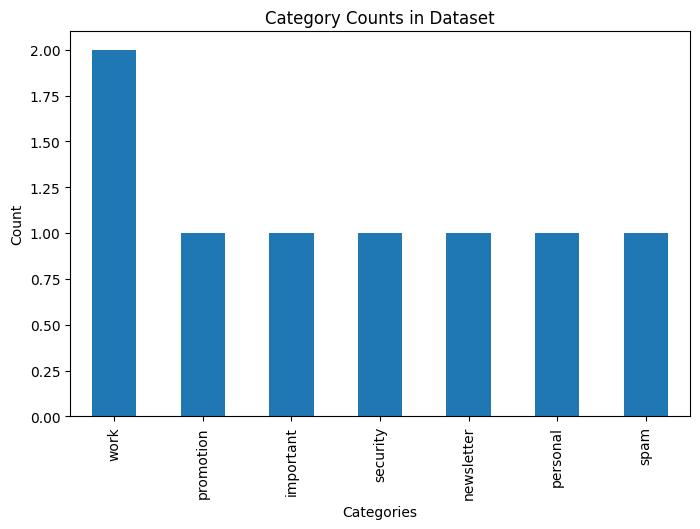

In [22]:
#Visualize category count using a Bar Chart

import pandas as pd
import matplotlib.pyplot as plt
# Count categories
category_counts = df['label'].value_counts()

# Plot bar chart
plt.figure(figsize=(8,5))
category_counts.plot(kind='bar')

plt.xlabel("Categories")
plt.ylabel("Count")
plt.title("Category Counts in Dataset")

plt.show()

In [ ]:
#Why we choose this new category 
""" 1. This category groups together emails that share a specific intent or content pattern, 
helping the model classify them more accurately instead of mixing them with generic labels.
2.Adding this category improves organization and automation, allowing downstream workflows 
(like alerts, tagging, prioritization) to run more smoothly.
3.The existing categories didn’t fully represent this type of email, 
so a new label ensures clearer separation and better filtering."""

In [ ]:
#How the rule detects this category
""" 1.The rule scans the subject and body for specific keywords or phrases strongly associated with 
this category (e.g., "login attempt", "OTP", "security alert").
2.It applies a pattern-matching condition, such as checking for multiple related words appearing together, 
to ensure the detection is accurate and not random.
3.The email is assigned this category only when the rule’s conditions evaluate to True, 
meaning the email content confidently matches the defined pattern."""

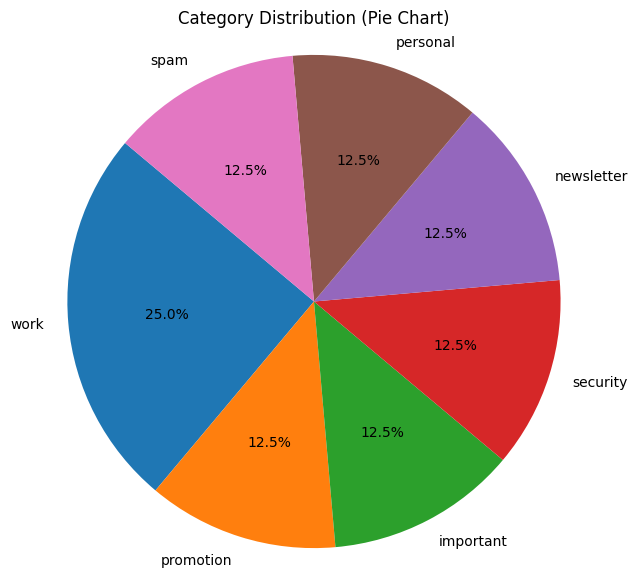

In [23]:
# Plot pie chart
plt.figure(figsize=(7, 7))
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', startangle=140)

plt.title("Category Distribution (Pie Chart)")
plt.axis('equal')  # Ensures the pie is circular

plt.show()

In [25]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# Combine subject + body text for better keyword extraction
df["combined_text"] = df["subject"] + " " + df["body"]

# TF-IDF Vectorizer
vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = vectorizer.fit_transform(df["combined_text"])

feature_names = vectorizer.get_feature_names_out()

# Function to extract top keywords for a given text row
def get_top_keywords(row_index, top_n=5):
    row = tfidf_matrix[row_index].toarray().flatten()
    top_indices = row.argsort()[-top_n:][::-1]
    return [feature_names[i] for i in top_indices]

# Extract 5 keywords per category
keywords_per_category = {}

for label in df["label"].unique():
    indices = df[df["label"] == label].index

    # Combine TF-IDF scores for all texts in this category
    category_scores = tfidf_matrix[indices].sum(axis=0)

    # Get top 5 terms
    top_indices = np.asarray(category_scores).flatten().argsort()[-5:][::-1]
    keywords = [feature_names[i] for i in top_indices]

    keywords_per_category[label] = keywords

# Display results
for category, keywords in keywords_per_category.items():
    print(f"\nCategory: {category}")
    print("Top 5 Keywords:", keywords)


Category: important
Top 5 Keywords: ['sign', 'letter', 'offer', 'upload', 'evening']

Category: promotion
Top 5 Keywords: ['visit', 'store', 'period', 'sale', 'limited']

Category: security
Top 5 Keywords: ['attempt', 'login', 'password', 'new', 'unusual']

Category: newsletter
Top 5 Keywords: ['weekly', 'week', 'tech', 'newsletter', 'langgraph']

Category: personal
Top 5 Keywords: ['weekend', 'coffee', 'hey', 'free', 'long']

Category: spam
Top 5 Keywords: ['000', 'won', 'click', 'claim', 'lottery']

Category: work
Top 5 Keywords: ['update', 'project', 'mandatory', 'training', 'required']


In [ ]:
#Define category keywords
category_keywords = {
    "important": ["offer", "letter", "sign", "congratulations", "company"],
    "promotion": ["sale", "off", "discount", "shop", "electronics"],
    "security": ["login", "attempt", "device", "verify", "unusual"],
    "newsletter": ["weekly", "newsletter", "tech", "edition", "update"],
    "personal": ["coffee", "weekend", "meet", "long", "time"]
}

#Function to detect category matches
def match_categories(text):
    matches = []
    text = text.lower()

    for category, keywords in category_keywords.items():
        if any(word in text for word in keywords):
            matches.append(category)

    return matches

#Apply detection to DataFrame
df["combined_text"] = df["subject"] + " " + df["body"]
df["matched_categories"] = df["combined_text"].apply(match_categories)
df["match_count"] = df["matched_categories"].apply(len)

#Highlight emails with multiple category matches
from IPython.display import display

def highlight_multi(row):
    if row["match_count"] > 1:
        return ['background-color: yellow'] * len(row)
    return [''] * len(row)

styled_df = df.style.apply(highlight_multi, axis=1)

display(styled_df)

multi_match_df = df[df["match_count"] > 1]
display(multi_match_df)


,id,sender,subject,body,priority,label,text,clean_text,is_spam_rule,subject_stemmed,body_stemmed,combined_text,matched_categories,match_count
0,1,hr@company.com,Offer Letter - Please Sign,"Dear Candidate, Congratulations! Please sign and upload your offer letter by today evening.",high,important,"Offer Letter - Please Sign Dear Candidate, Congratulations! Please sign and upload your offer letter by today evening.",dear candidate congratulations please sign and upload your offer letter by today evening,1,offer letter - pleas sign,"dear candid , congratul ! pleas sign and upload your offer letter by today even .","Offer Letter - Please Sign Dear Candidate, Congratulations! Please sign and upload your offer letter by today evening.","['important', 'promotion']",2
1,2,noreply@shopping.com,Big Billion Sale is Live,Flat 70% OFF on electronics. Limited period offer. Visit our store now.,low,promotion,Big Billion Sale is Live Flat 70% OFF on electronics. Limited period offer. Visit our store now.,flat off on electronics limited period offer visit our store now,1,big billion sale is live,flat 70 % off on electron . limit period offer . visit our store now .,Big Billion Sale is Live Flat 70% OFF on electronics. Limited period offer. Visit our store now.,"['important', 'promotion']",2
2,3,alerts@mybank.com,Unusual Login Attempt,"We detected a login attempt to your account from a new device. If this was not you, please reset your password.",high,security,"Unusual Login Attempt We detected a login attempt to your account from a new device. If this was not you, please reset your password.",we detected a login attempt to your account from a new device if this was not you please reset your password,0,unusu login attempt,"we detect a login attempt to your account from a new devic . if thi wa not you , pleas reset your password .","Unusual Login Attempt We detected a login attempt to your account from a new device. If this was not you, please reset your password.",['security'],1
3,4,newsletter@blog.com,Weekly Tech Newsletter,"In this week's edition, learn about AI agents, LangGraph, and more.",low,newsletter,"Weekly Tech Newsletter In this week's edition, learn about AI agents, LangGraph, and more.",in this week s edition learn about ai agents langgraph and more,0,weekli tech newslett,"in thi week 's edit , learn about ai agent , langgraph , and more .","Weekly Tech Newsletter In this week's edition, learn about AI agents, LangGraph, and more.","['important', 'newsletter']",2
4,5,friend123@gmail.com,Coffee this weekend?,"Hey, long time no see! Are you free this weekend for coffee?",medium,personal,"Coffee this weekend? Hey, long time no see! Are you free this weekend for coffee?",hey long time no see are you free this weekend for coffee,1,coffe thi weekend ?,"hey , long time no see ! are you free thi weekend for coffe ?","Coffee this weekend? Hey, long time no see! Are you free this weekend for coffee?","['promotion', 'personal']",2
5,6,spam@strange-domain.ru,"You won $1,000,000!!!",Click here to claim your lottery now. Do not share this with anyone.,high,spam,"You won $1,000,000!!! Click here to claim your lottery now. Do not share this with anyone.",click here to claim your lottery now do not share this with anyone,1,"you won $ 1,000,000 ! ! !",click here to claim your lotteri now . do not share thi with anyon .,"You won $1,000,000!!! Click here to claim your lottery now. Do not share this with anyone.",[],0
6,7,manager@company.com,Project Update Required,Please share the status update of your project before 5 PM today.,high,work,Project Update Required Please share the status update of your project before 5 PM today.,please share the status update of your project before pm today,0,project updat requir,pleas share the statu updat of your project befor 5 pm today .,Project Update Required Please share the status update of your project before 5 PM today.,['newsletter'],1
7,8,training@lms.com,Reminder: Complete Mandatory Training,Your mandatory 

,id,sender,subject,body,priority,label,text,clean_text,is_spam_rule,subject_stemmed,body_stemmed,combined_text,matched_categories,match_count
0,1,hr@company.com,Offer Letter - Please Sign,"Dear Candidate, Congratulations! Please sign a...",high,important,"Offer Letter - Please Sign Dear Candidate, Con...",dear candidate congratulations please sign a...,1,offer letter - pleas sign,"dear candid , congratul ! pleas sign and uploa...","Offer Letter - Please Sign Dear Candidate, Con...","[important, promotion]",2
1,2,noreply@shopping.com,Big Billion Sale is Live,Flat 70% OFF on electronics. Limited period of...,low,promotion,Big Billion Sale is Live Flat 70% OFF on elect...,flat off on electronics limited period of...,1,big billion sale is live,flat 70 % off on electron . limit period offer...,Big Billion Sale is Live Flat 70% OFF on elect...,"[important, promotion]",2
3,4,newsletter@blog.com,Weekly Tech Newsletter,"In this week's edition, learn about AI agents,...",low,newsletter,"Weekly Tech Newsletter In this week's edition,...",in this week s edition learn about ai agents ...,0,weekli tech newslett,"in thi week 's edit , learn about ai agent , l...","Weekly Tech Newsletter In this week's edition,...","[important, newsletter]",2
4,5,friend123@gmail.com,Coffee this weekend?,"Hey, long time no see! Are you free this weeke...",medium,personal,"Coffee this weekend? Hey, long time no see! Ar...",hey long time no see are you free this weeke...,1,coffe thi weekend ?,"hey , long time no see ! are you free thi week...","Coffee this weekend? Hey, long time no see! Ar...","[promotion, personal]",2
